## 1. Importando as bibliotecas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

## 2. Leitura dos dados

In [3]:
url_base = "https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv"

df = pd.read_csv(url_base)
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


## 3. Analisando características da tabela

In [4]:
print("Shape do df:",df.shape)
print("Granularidade dos pedidos:", df["order_id"].nunique())

Shape do df: (2500, 19)
Granularidade dos pedidos: 2500


## 4. Criando variáveis de negócio e renomeando as colunas

In [5]:
df["atraso_pedido"] = np.where(
    df['delivery_delay_days'].isna(),
    np.nan,
    np.where(df['delivery_delay_days'] > 0, 1, 0)
)

df["status_pedido"] = np.where(
    df["atraso_pedido"].isna(),
    None,
    np.where(df["atraso_pedido"] == 1, "Com atraso", "Sem atraso")
)

df = df.rename(columns={
    "customer_id": "id_cliente",
    "customer_age": "idade_cliente",
    "customer_region": "regiao_cliente",
    "customer_tenure_months": "tempo_cliente_meses",
    "order_id": "id_pedido",
    "order_value": "valor_pedido",
    "items_quantity": "quantidade_itens",
    "discount_value": "valor_desconto",
    "payment_installments": "parcelas_pagamento",
    "delivery_time_days": "tempo_entrega_dias",
    "delivery_delay_days": "atraso_entrega_dias",
    "freight_value": "valor_frete",
    "delivery_attempts": "tentativas_entrega",
    "customer_service_contacts": "contatos_suporte",
    "resolution_time_days": "tempo_resolucao_dias",
    "nps_score": "nps",
    "repeat_purchase_30d": "recompra_30d",
    "complaints_count": "quantidade_reclamacoes",
    "csat_internal_score": "csat_interno"
})
df.head()

def classificar_nps(score):
    if score <= 6:
        return "Detrator"
    elif score <= 8:
        return "Neutro"
    else:
        return "Promotor"

df["categoria_nps"] = df["nps"].apply(classificar_nps)
order = ["Detrator", "Neutro", "Promotor"]
cores = {"Detrator": "#e74c3c", "Neutro": "#f39c12", "Promotor": "#2ecc71"}


## 5. Visão geral do df

In [6]:
df.info()
df.describe(include="all").T.head(30)

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              2500 non-null   int64  
 1   idade_cliente           2500 non-null   int64  
 2   regiao_cliente          2500 non-null   str    
 3   tempo_cliente_meses     2500 non-null   int64  
 4   id_pedido               2500 non-null   int64  
 5   valor_pedido            2500 non-null   float64
 6   quantidade_itens        2500 non-null   int64  
 7   valor_desconto          2500 non-null   float64
 8   parcelas_pagamento      2500 non-null   int64  
 9   tempo_entrega_dias      2500 non-null   int64  
 10  atraso_entrega_dias     2500 non-null   int64  
 11  valor_frete             2500 non-null   float64
 12  tentativas_entrega      2500 non-null   int64  
 13  contatos_suporte        2500 non-null   int64  
 14  tempo_resolucao_dias    2500 non-null   int64  
 15

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_cliente,"2,500.00",NaN,NaN,NaN,"1,250.50",721.83,1.00,625.75,"1,250.50","1,875.25","2,500.00"
idade_cliente,"2,500.00",NaN,NaN,NaN,43.40,14.89,18.00,31.00,43.00,56.00,69.00
regiao_cliente,2500,5,Sul,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tempo_cliente_meses,"2,500.00",NaN,NaN,NaN,61.32,34.48,1.00,31.00,62.00,91.00,119.00
id_pedido,"2,500.00",NaN,NaN,NaN,"51,250.50",721.83,"50,001.00","50,625.75","51,250.50","51,875.25","52,500.00"
valor_pedido,"2,500.00",NaN,NaN,NaN,434.26,289.77,7.76,220.25,375.51,577.29,"1,983.81"
quantidade_itens,"2,500.00",NaN,NaN,NaN,3.47,1.69,1.00,2.00,3.00,5.00,6.00
valor_desconto,"2,500.00",NaN,NaN,NaN,29.75,29.23,0.02,8.88,20.94,40.83,230.33
parcelas_pagamento,"2,500.00",NaN,NaN,NaN,6.00,3.16,1.00,3.00,6.00,9.00,11.00
tempo_entrega_dias,"2,500.00",NaN,NaN,NaN,8.02,3.77,2.00,5.00,8.00,11.00,14.00


## 6. Quantidade de atrasos e atrasos por região

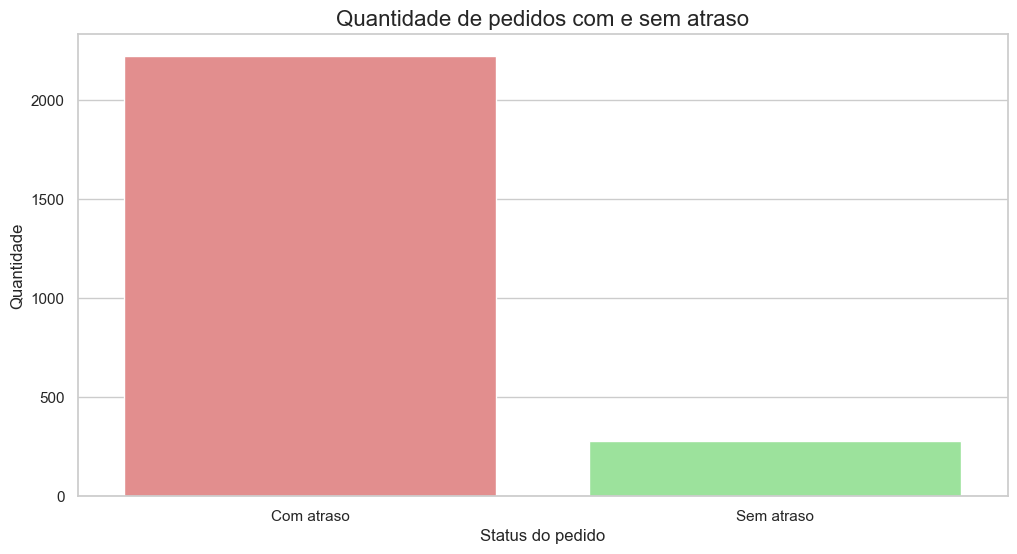

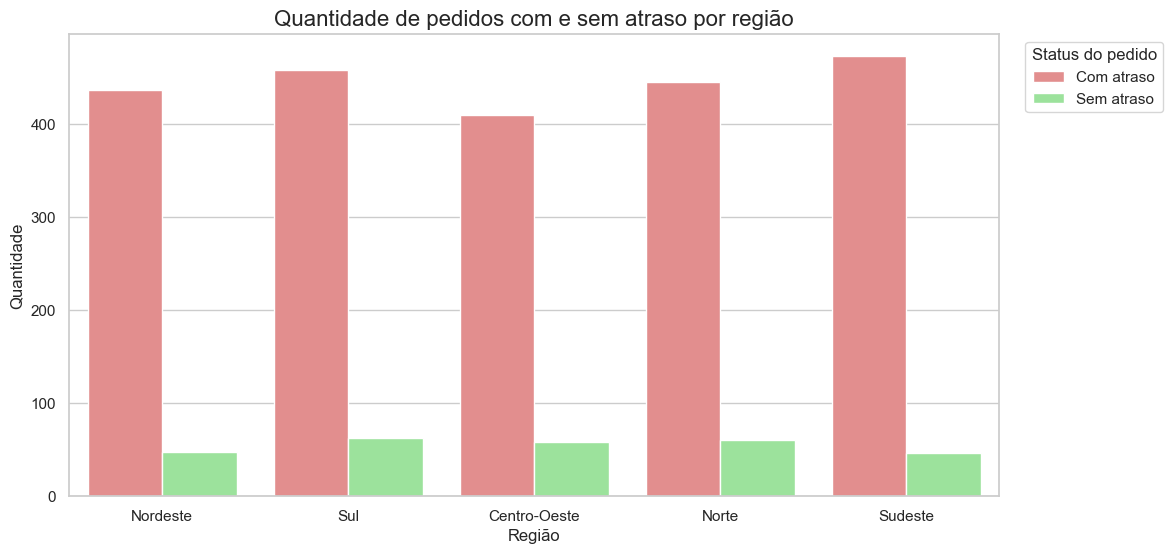

In [7]:
sns.countplot(
    data=df,
    x="status_pedido",
    palette={"Com atraso": "lightcoral", "Sem atraso": "lightgreen"}
)

plt.title("Quantidade de pedidos com e sem atraso")
plt.xlabel("Status do pedido")
plt.ylabel("Quantidade")
plt.show()

sns.countplot(
    data=df,
    x="regiao_cliente",
    hue="status_pedido",
    palette={"Com atraso": "lightcoral", "Sem atraso": "lightgreen"}
)
plt.title("Quantidade de pedidos com e sem atraso por região")
plt.xlabel("Região")
plt.ylabel("Quantidade")
plt.legend(title="Status do pedido",
           bbox_to_anchor=(1.02,1),
           loc="upper left")
plt.show()

## 7. Analise geral atributos relacionados ao pedido

#### 7.1 Valor do Pedido

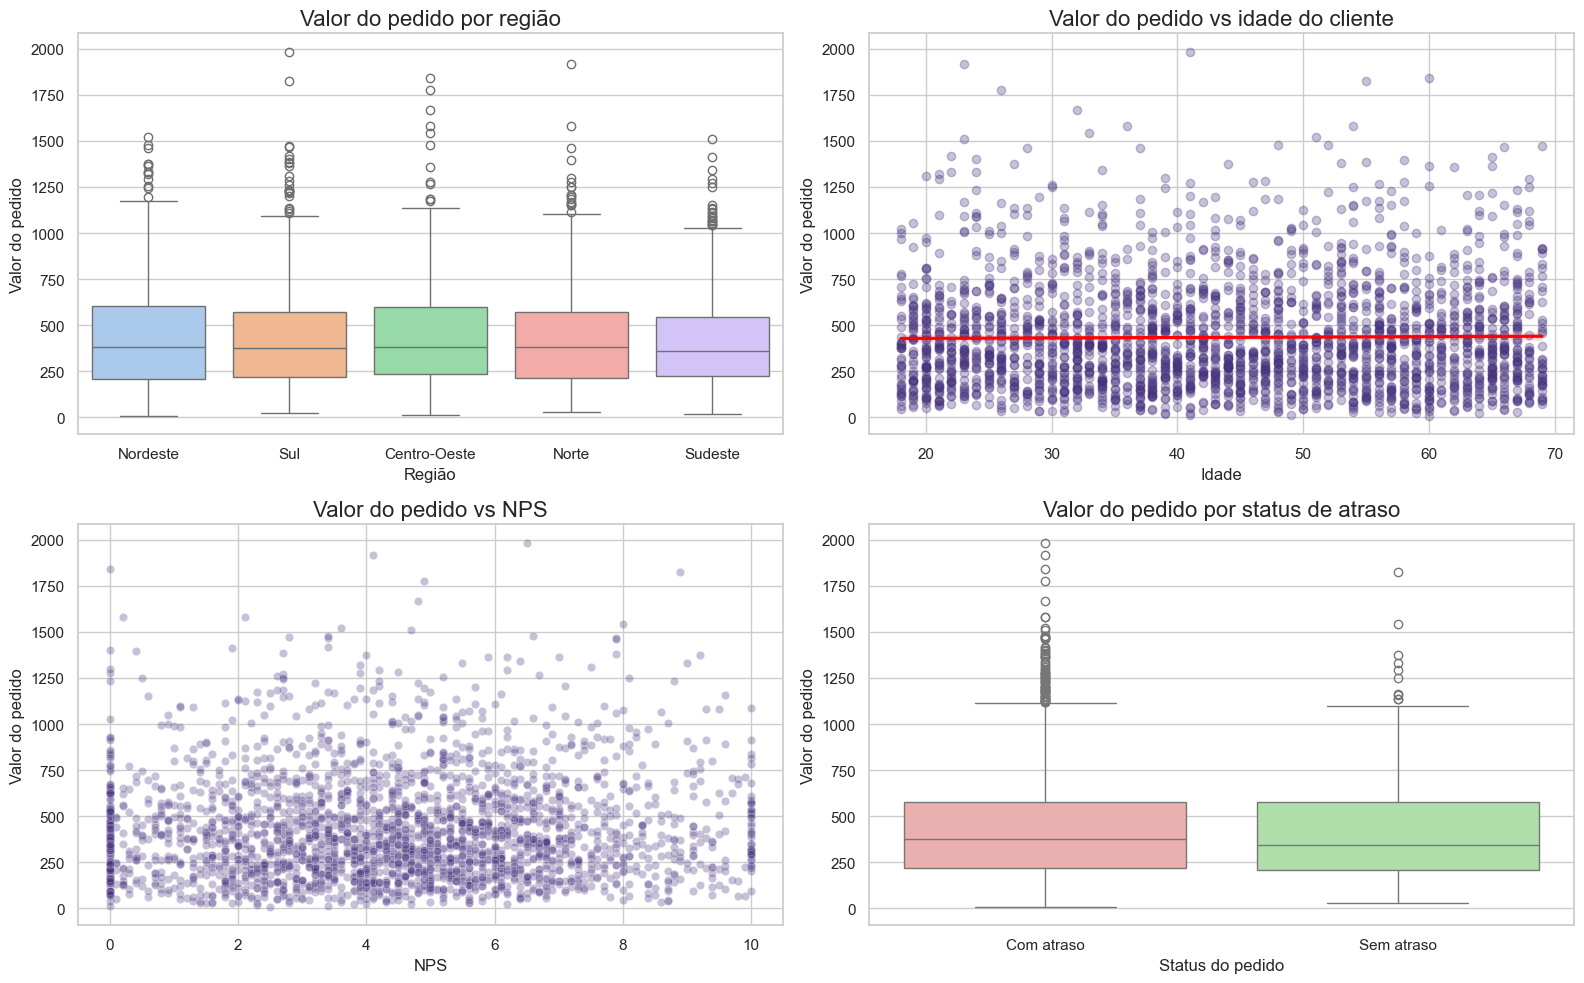

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(
    data=df,
    x="regiao_cliente",
    y="valor_pedido",
    ax=axes[0, 0],
    palette="pastel"
)
axes[0, 0].set_title("Valor do pedido por região")
axes[0, 0].set_xlabel("Região")
axes[0, 0].set_ylabel("Valor do pedido")

sns.regplot(
    data=df,
    x="idade_cliente",
    y="valor_pedido",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[0, 1]
)
axes[0, 1].set_title("Valor do pedido vs idade do cliente")
axes[0, 1].set_xlabel("Idade")
axes[0, 1].set_ylabel("Valor do pedido")

sns.scatterplot(
    data=df,
    x="nps",
    y="valor_pedido",
    alpha=0.3,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Valor do pedido vs NPS")
axes[1, 0].set_xlabel("NPS")
axes[1, 0].set_ylabel("Valor do pedido")

sns.boxplot(
    data=df,
    x="status_pedido",
    y="valor_pedido",
    palette={"Com atraso": "#f4a6a6", "Sem atraso": "#a8e6a3"},
    ax=axes[1, 1]
)
axes[1, 1].set_title("Valor do pedido por status de atraso")
axes[1, 1].set_xlabel("Status do pedido")
axes[1, 1].set_ylabel("Valor do pedido")

plt.tight_layout()
plt.show()

##### Análise do valor do pedido, isoladamente, não permite tirar conclusões relevantes sobre o comportamento dos clientes ou os fatores que impactam o NPS. Os dados apresentam alta dispersão e não indicam correlações claras com variáveis como região, idade, satisfação ou status de atraso.

#### 7.2 Quantidade de itens do pedido

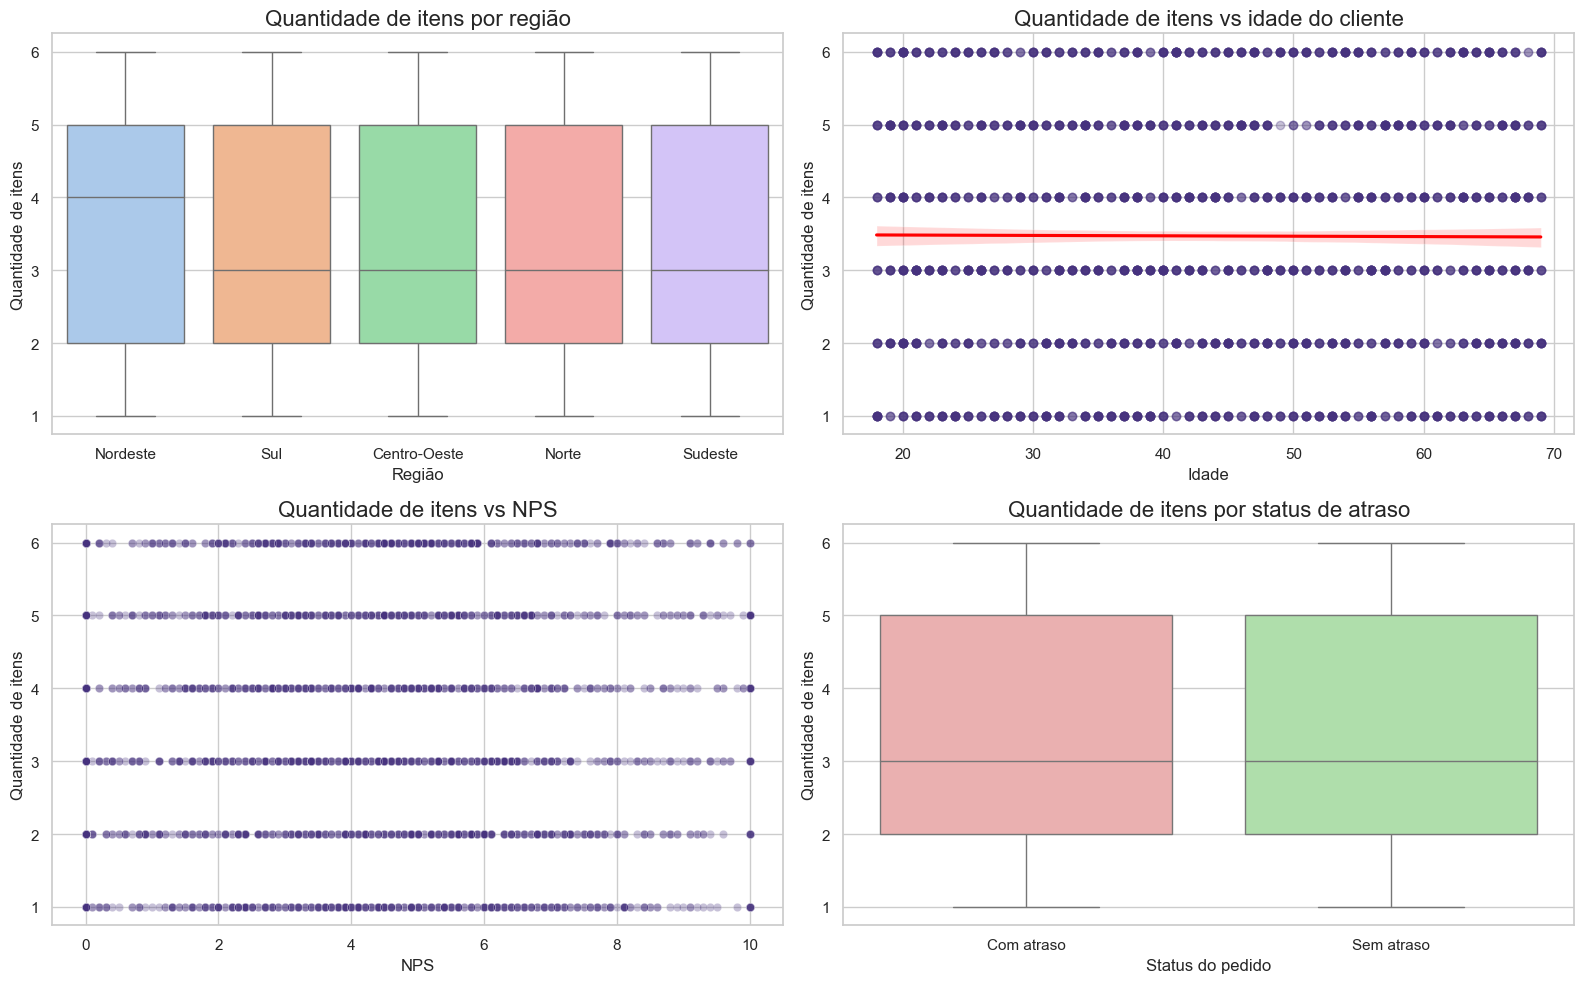

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(
    data=df,
    x="regiao_cliente",
    y="quantidade_itens",
    palette="pastel",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Quantidade de itens por região")
axes[0, 0].set_xlabel("Região")
axes[0, 0].set_ylabel("Quantidade de itens")

sns.regplot(
    data=df,
    x="idade_cliente",
    y="quantidade_itens",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[0, 1]
)
axes[0, 1].set_title("Quantidade de itens vs idade do cliente")
axes[0, 1].set_xlabel("Idade")
axes[0, 1].set_ylabel("Quantidade de itens")

sns.scatterplot(
    data=df,
    x="nps",
    y="quantidade_itens",
    alpha=0.3,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Quantidade de itens vs NPS")
axes[1, 0].set_xlabel("NPS")
axes[1, 0].set_ylabel("Quantidade de itens")

sns.boxplot(
    data=df,
    x="status_pedido",
    y="quantidade_itens",
    palette={"Com atraso": "#f4a6a6", "Sem atraso": "#a8e6a3"},
    ax=axes[1, 1]
)
axes[1, 1].set_title("Quantidade de itens por status de atraso")
axes[1, 1].set_xlabel("Status do pedido")
axes[1, 1].set_ylabel("Quantidade de itens")

plt.tight_layout()
plt.show()

##### A análise da quantidade de itens por pedido também não permite identificar padrões ou relações relevantes. As distribuições são muito semelhantes entre regiões, idades, níveis de NPS e status de atraso, sem apresentar variações significativas.

## 8. Analise do NPS pelos demais atributos da base

#### 8.1 Analisando o NPS com suas categorias

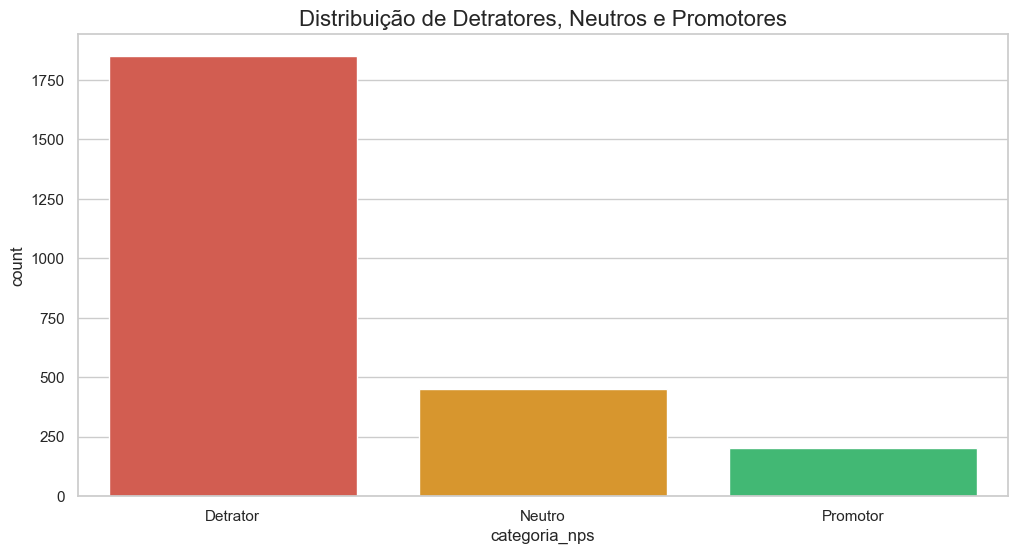

               Quantidade     %
categoria_nps                  
Detrator             1851 74.00
Neutro                448 17.90
Promotor              201  8.00

NPS Score: -66.0


In [10]:
sns.countplot(data=df, x="categoria_nps", order=order, palette=cores)
plt.title("Distribuição de Detratores, Neutros e Promotores")
plt.show()

promotores = (df["categoria_nps"] == "Promotor").sum()
detratores = (df["categoria_nps"] == "Detrator").sum()
nps_score = round((promotores - detratores) / len(df) * 100, 1)

dist = df["categoria_nps"].value_counts()
dist_pct = df["categoria_nps"].value_counts(normalize=True) * 100

resumo_nps = pd.DataFrame({
    "Quantidade": dist,
    "%": dist_pct.round(1)
}).loc[["Detrator", "Neutro", "Promotor"]]

print(resumo_nps)
print(f"\nNPS Score: {round((dist.get('Promotor',0) - dist.get('Detrator',0)) / len(df) * 100, 1)}")

#### 8.2 Analise NPS por status pedido

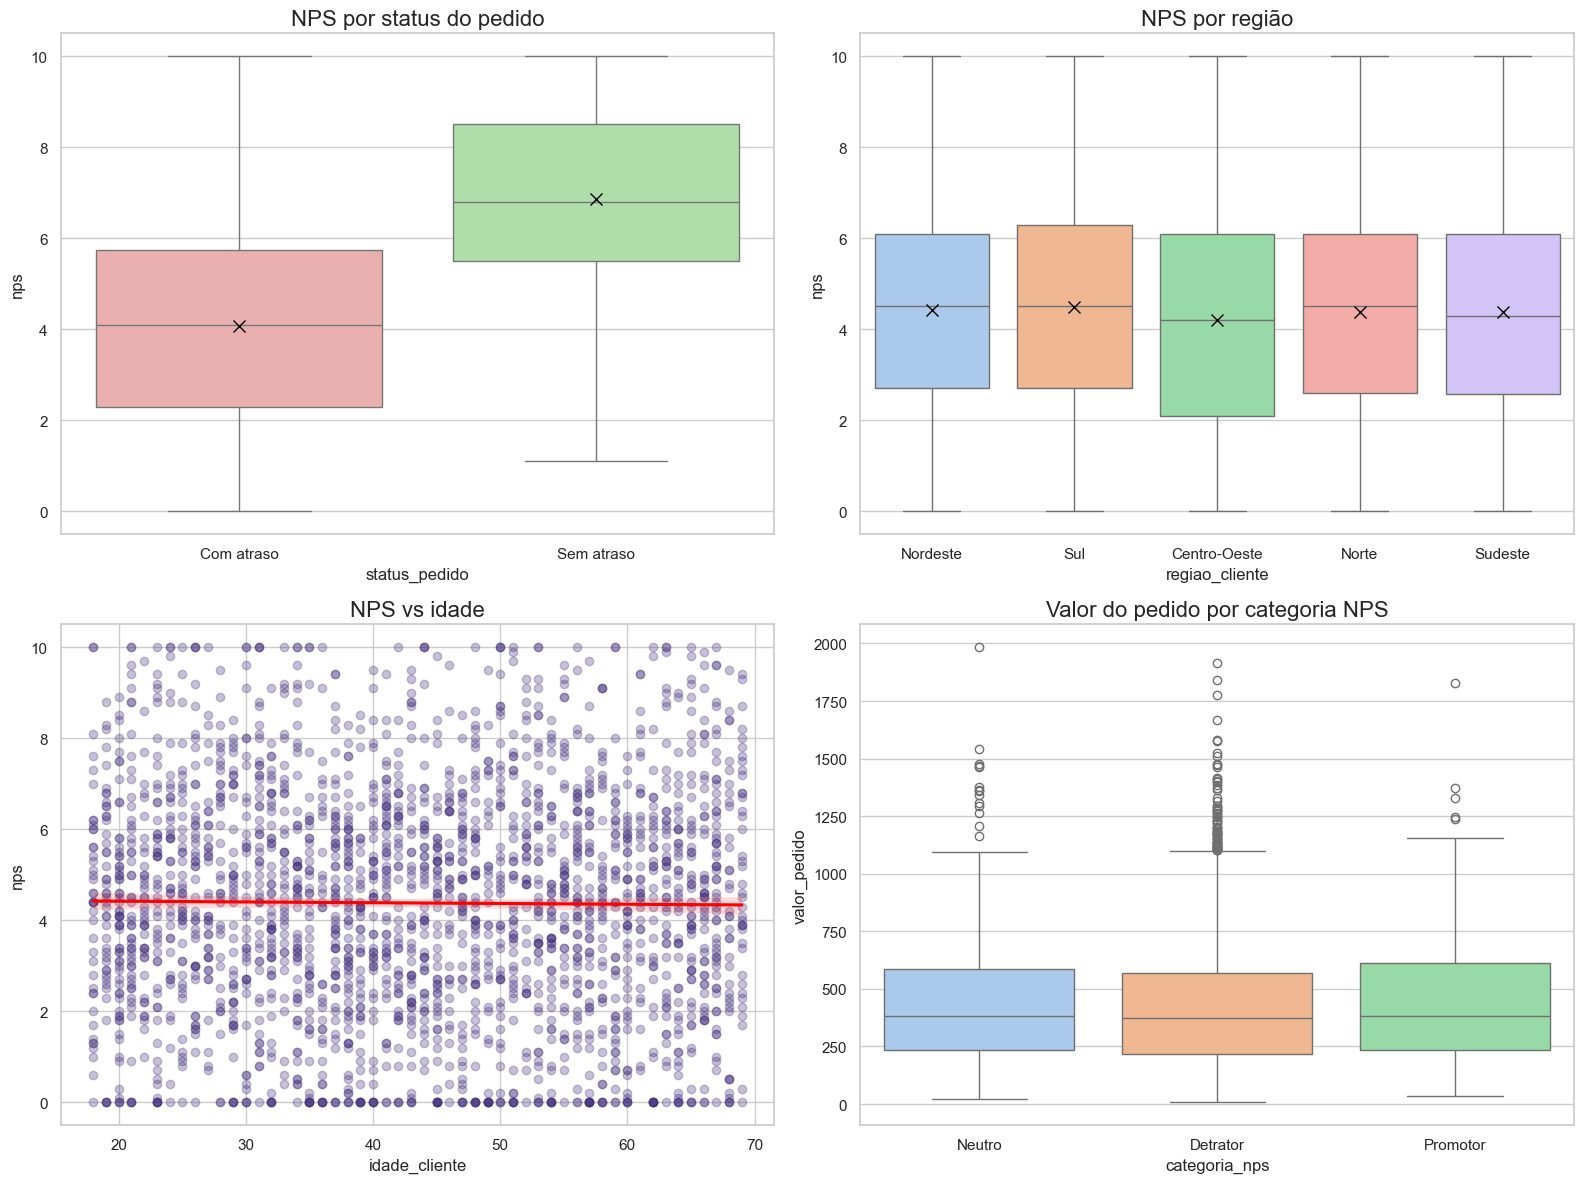

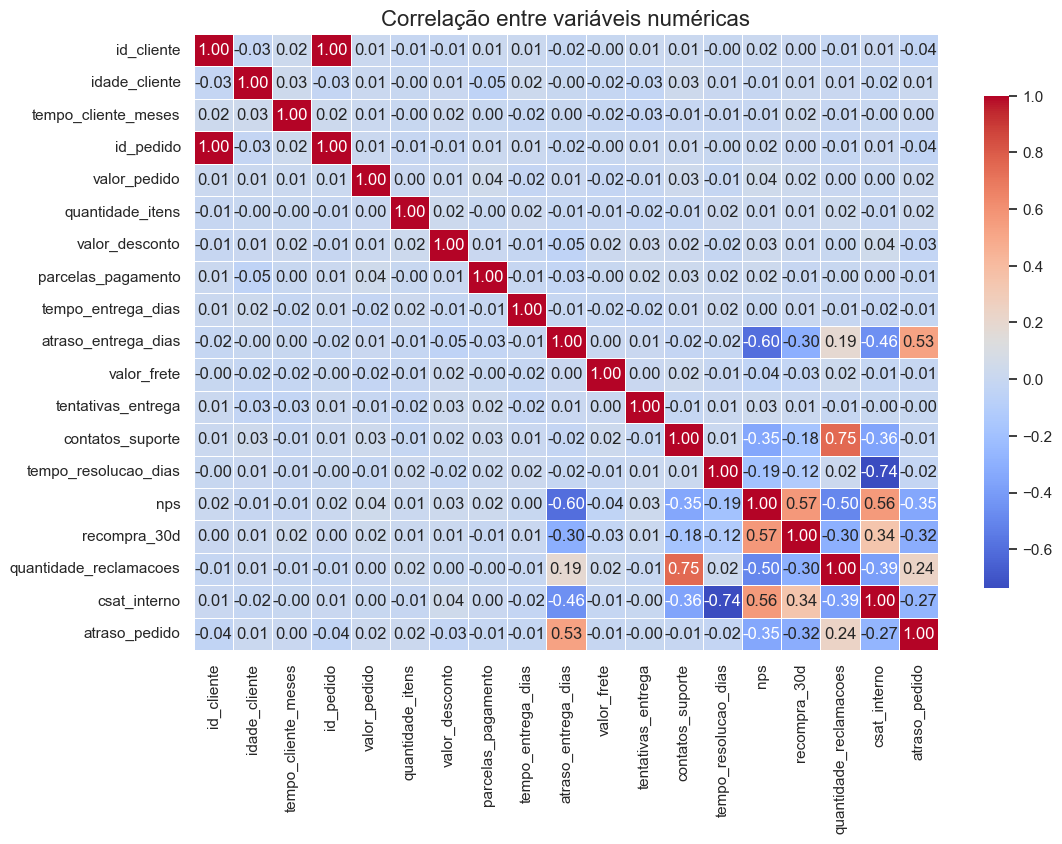

In [11]:
nps_por_status = df.groupby("status_pedido")["nps"].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(
    data=df,
    x="status_pedido",
    y="nps",
    palette={"Com atraso": "#f4a6a6", "Sem atraso": "#a8e6a3"},
    showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black", "markersize": 8},
    ax=axes[0, 0]
)
axes[0, 0].set_title("NPS por status do pedido")

sns.boxplot(
    data=df,
    x="regiao_cliente",
    y="nps",
    palette="pastel",
    showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black", "markersize": 8},
    ax=axes[0, 1]
)
axes[0, 1].set_title("NPS por região")

sns.regplot(
    data=df,
    x="idade_cliente",
    y="nps",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1, 0]
)
axes[1, 0].set_title("NPS vs idade")

sns.boxplot(
    data=df,
    x="categoria_nps",
    y="valor_pedido",
    palette="pastel",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Valor do pedido por categoria NPS")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlação entre variáveis numéricas")
plt.show()

##### Diferente das análises anteriores, o NPS apresenta variações claras quando analisado em relação a fatores operacionais.
##### Pedidos com atraso possuem NPS significativamente menor em comparação aos pedidos sem atraso, indicando impacto direto na satisfação do cliente.
##### A matriz de correlação reforça esse comportamento, evidenciando que fatores como atraso, tempo de resolução e volume de interações com suporte possuem relação significativa com o NPS.

#### 8.3 Analise das categorias do NPS por demais atributos

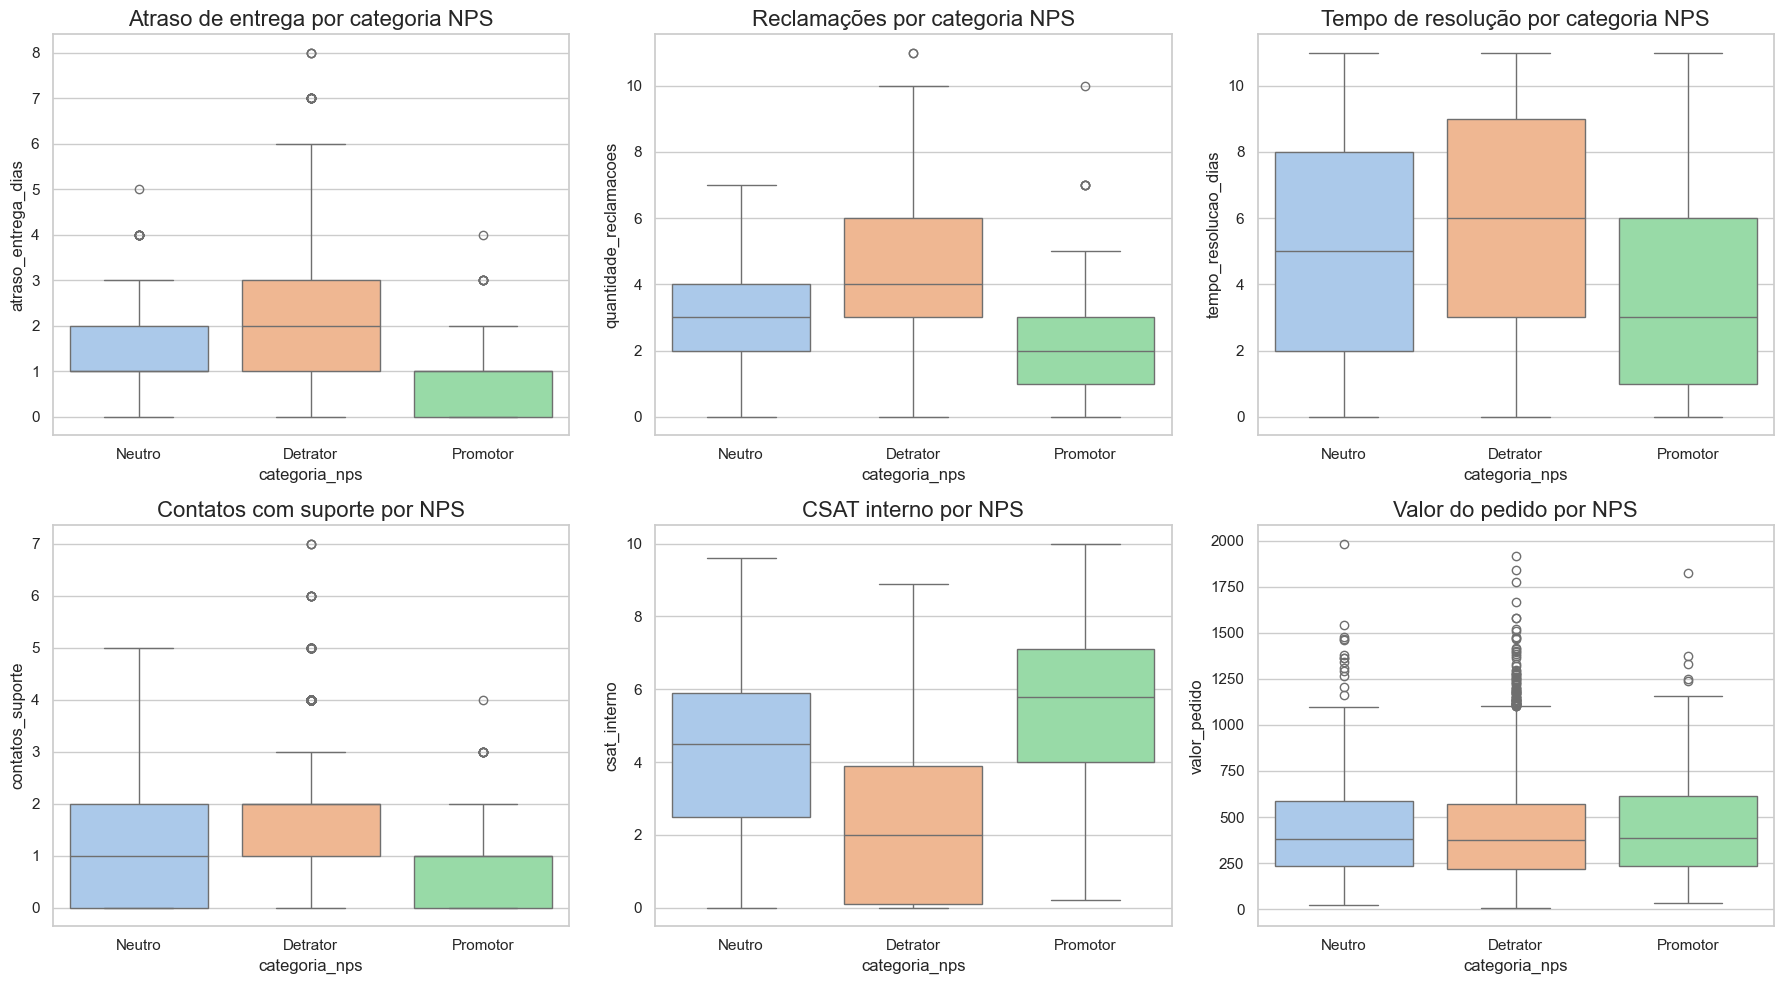

In [12]:
df_detratores = df[df["categoria_nps"] == "Detrator"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(
    data=df,
    x="categoria_nps",
    y="atraso_entrega_dias",
    palette="pastel",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Atraso de entrega por categoria NPS")

sns.boxplot(
    data=df,
    x="categoria_nps",
    y="quantidade_reclamacoes",
    palette="pastel",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Reclamações por categoria NPS")

sns.boxplot(
    data=df,
    x="categoria_nps",
    y="tempo_resolucao_dias",
    palette="pastel",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Tempo de resolução por categoria NPS")

sns.boxplot(
    data=df,
    x="categoria_nps",
    y="contatos_suporte",
    palette="pastel",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Contatos com suporte por NPS")

sns.boxplot(
    data=df,
    x="categoria_nps",
    y="csat_interno",
    palette="pastel",
    ax=axes[1, 1]
)
axes[1, 1].set_title("CSAT interno por NPS")

sns.boxplot(
    data=df,
    x="categoria_nps",
    y="valor_pedido",
    palette="pastel",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Valor do pedido por NPS")

plt.tight_layout()
plt.show()

##### Ao analisar o NPS por fatores operacionais, é notável uma relação clara entre a experiência do cliente e seu nível de satisfação.
##### Clientes detratores apresentam maiores níveis de atraso, maior volume de reclamações, mais interações com o suporte e maior tempo de resolução.
##### Clientes promotores estão associados a operações mais eficientes, com menos atritos ao longo da jornada.
##### O CSAT interno acompanha diretamente o NPS, reforçando a consistência da experiência percebida.

#### 8.4 Análise detalhada dos detratores

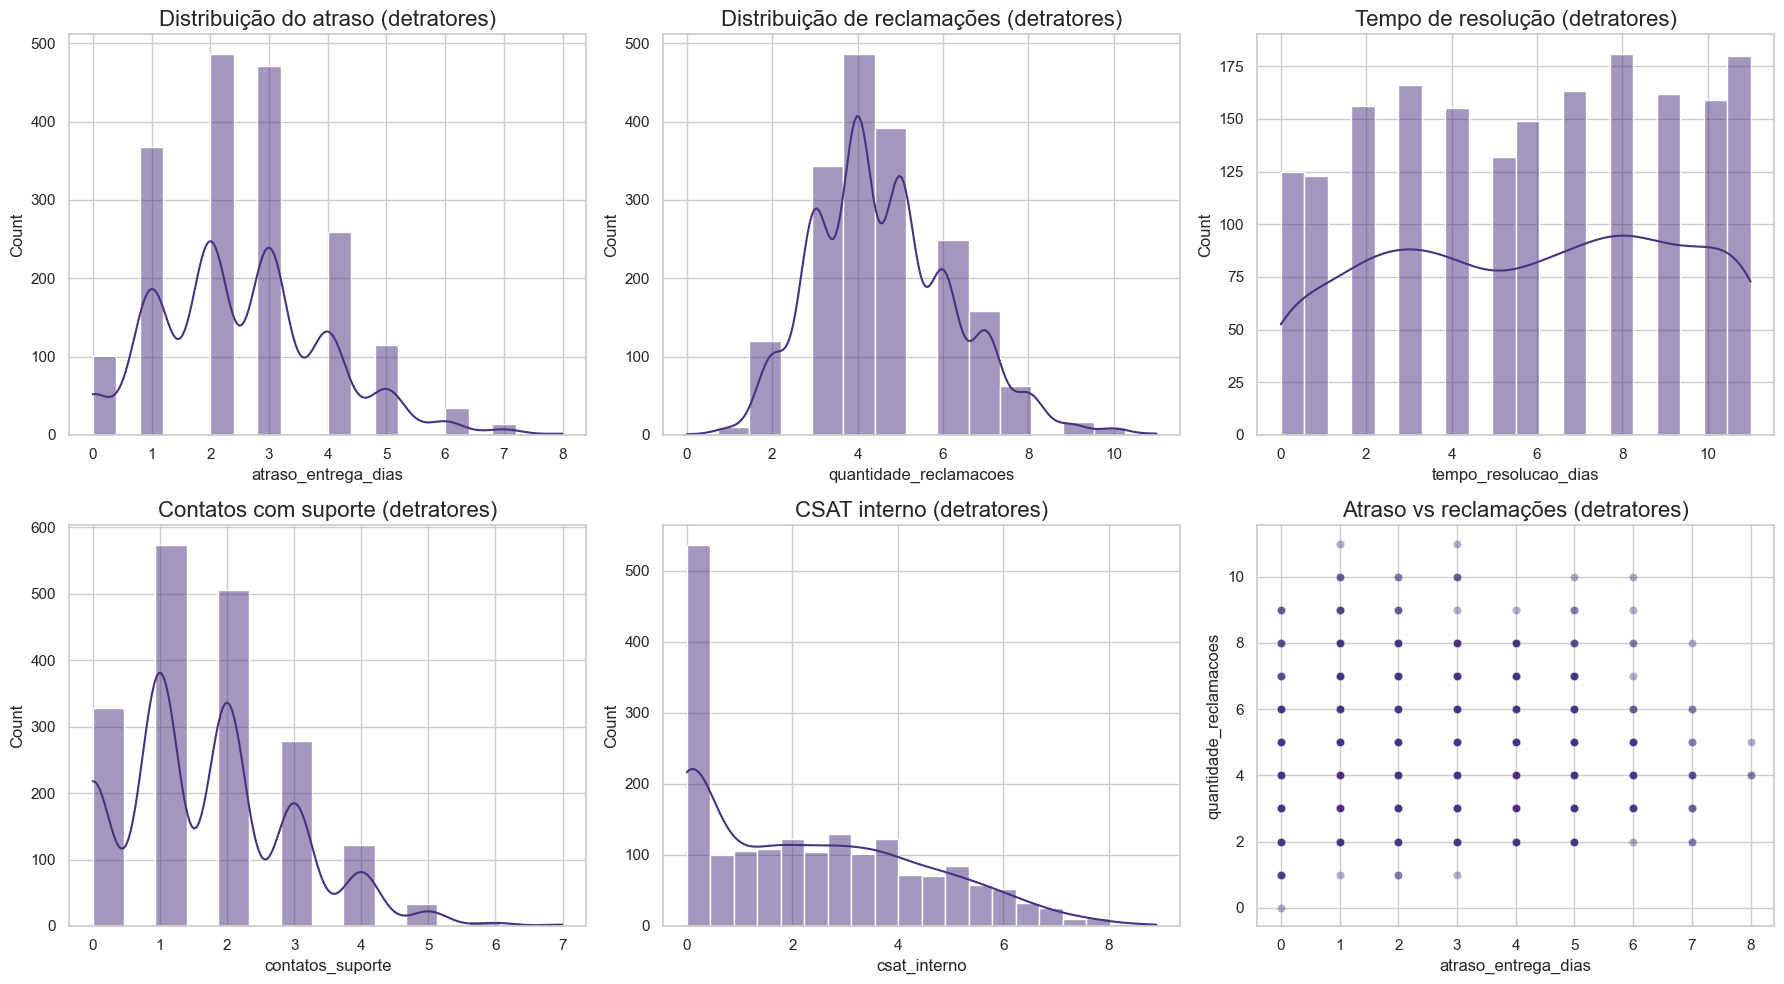

In [13]:
df_detratores = df[df["categoria_nps"] == "Detrator"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(
    data=df_detratores,
    x="atraso_entrega_dias",
    bins=20,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Distribuição do atraso (detratores)")

sns.histplot(
    data=df_detratores,
    x="quantidade_reclamacoes",
    bins=15,
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Distribuição de reclamações (detratores)")

sns.histplot(
    data=df_detratores,
    x="tempo_resolucao_dias",
    bins=20,
    kde=True,
    ax=axes[0, 2]
)
axes[0, 2].set_title("Tempo de resolução (detratores)")

sns.histplot(
    data=df_detratores,
    x="contatos_suporte",
    bins=15,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Contatos com suporte (detratores)")

sns.histplot(
    data=df_detratores,
    x="csat_interno",
    bins=20,
    kde=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title("CSAT interno (detratores)")

sns.scatterplot(
    data=df_detratores,
    x="atraso_entrega_dias",
    y="quantidade_reclamacoes",
    alpha=0.4,
    ax=axes[1, 2]
)
axes[1, 2].set_title("Atraso vs reclamações (detratores)")

plt.tight_layout()
plt.show()

##### Os dados mostram que esses clientes enfrentam maiores atrasos de entrega, com distribuição concentrada entre 1 e 4 dias, além de um volume elevado de reclamações, geralmente entre 3 e 6 ocorrências.
##### Também é possível identificar maior necessidade de interação com o suporte e tempos de resolução mais longos, indicando dificuldade na solução dos problemas enfrentados.
##### O CSAT interno acompanha esse comportamento, apresentando níveis mais baixos, o que reforça a percepção negativa da experiência.

## 9. Impacto da experiência do cliente na recompra

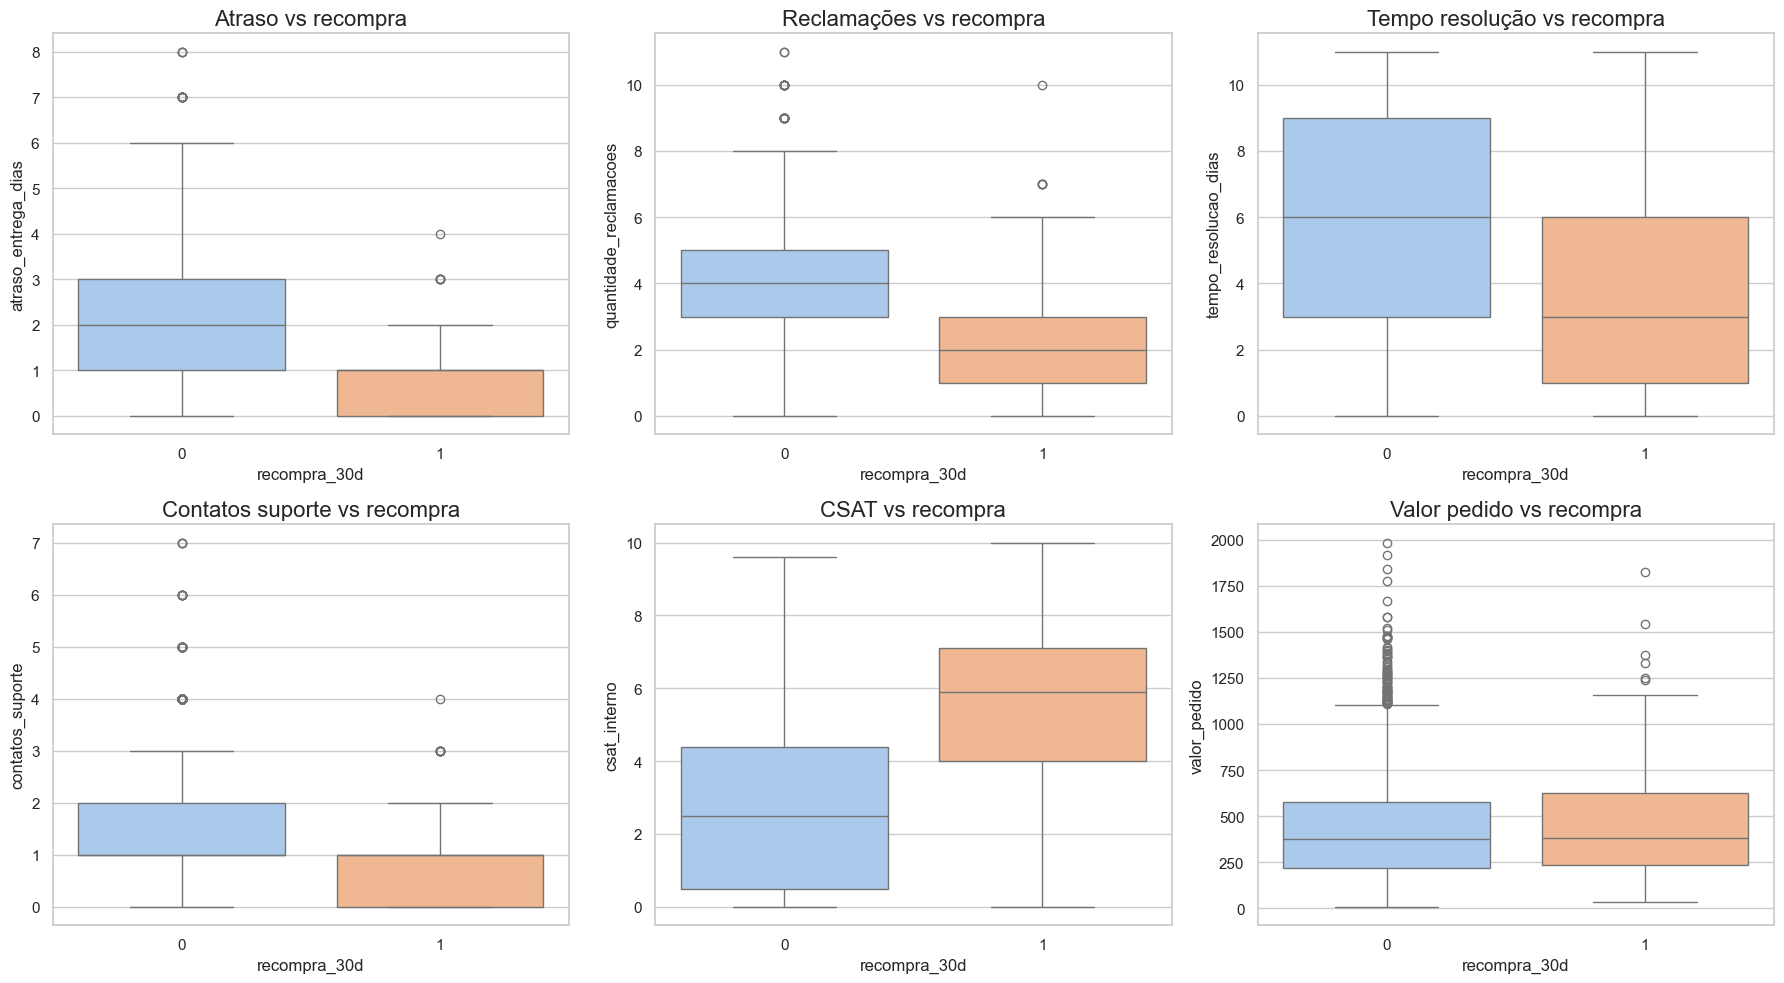

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(
    data=df,
    x="recompra_30d",
    y="atraso_entrega_dias",
    palette="pastel",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Atraso vs recompra")

sns.boxplot(
    data=df,
    x="recompra_30d",
    y="quantidade_reclamacoes",
    palette="pastel",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Reclamações vs recompra")

sns.boxplot(
    data=df,
    x="recompra_30d",
    y="tempo_resolucao_dias",
    palette="pastel",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Tempo resolução vs recompra")

sns.boxplot(
    data=df,
    x="recompra_30d",
    y="contatos_suporte",
    palette="pastel",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Contatos suporte vs recompra")

sns.boxplot(
    data=df,
    x="recompra_30d",
    y="csat_interno",
    palette="pastel",
    ax=axes[1, 1]
)
axes[1, 1].set_title("CSAT vs recompra")

sns.boxplot(
    data=df,
    x="recompra_30d",
    y="valor_pedido",
    palette="pastel",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Valor pedido vs recompra")

plt.tight_layout()
plt.show()

##### Análise de recompra evidencia uma relação direta entre a experiência operacional e o comportamento futuro do cliente.
##### Clientes que não retornam apresentam maiores níveis de atraso, maior volume de reclamações, mais interações com o suporte e tempos de resolução mais elevados.
##### Clientes que realizam recompra estão associados a uma jornada mais fluida, com menos fricções operacionais e níveis mais altos de CSAT interno.

#### 9.1 NPS como indicador direto de recompra

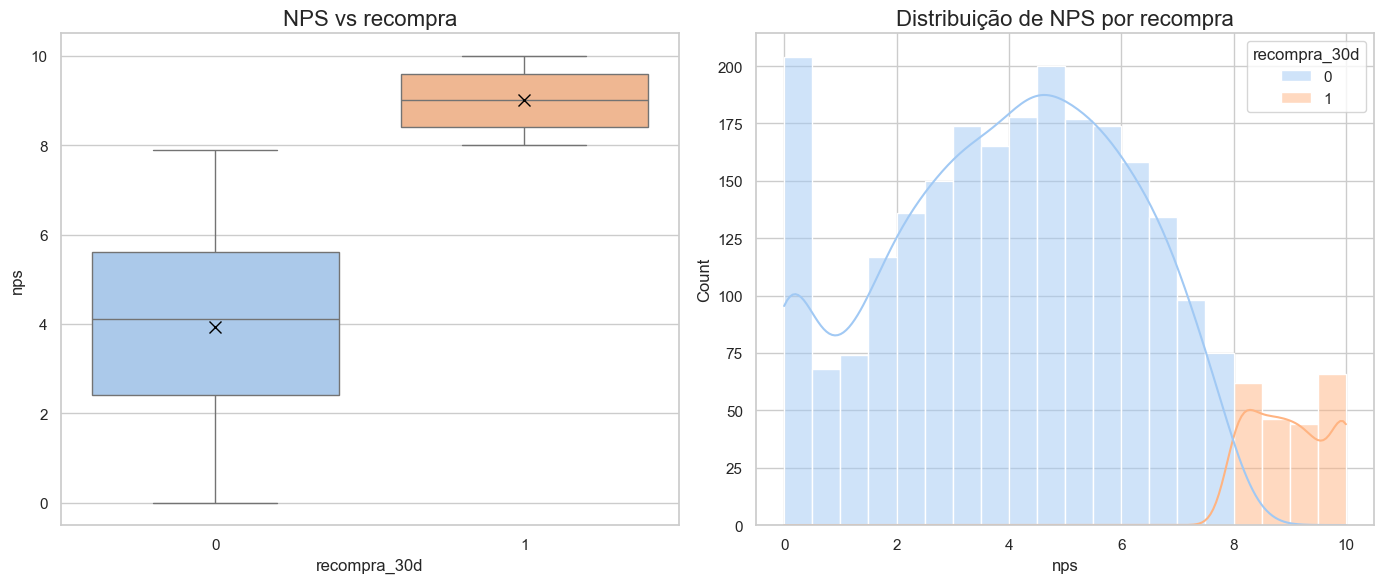

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df,
    x="recompra_30d",
    y="nps",
    palette="pastel",
    showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black", "markersize": 8},
    ax=axes[0]
)
axes[0].set_title("NPS vs recompra")

sns.histplot(
    data=df,
    x="nps",
    hue="recompra_30d",
    bins=20,
    kde=True,
    palette="pastel",
    ax=axes[1]
)
axes[1].set_title("Distribuição de NPS por recompra")

plt.tight_layout()
plt.show()

##### A relação entre NPS e recompra demonstra um padrão claro e consistente: clientes com maior nível de satisfação apresentam maior propensão a realizar novas compras.
##### Observa-se que clientes que não retornam concentram-se em faixas mais baixas de NPS, enquanto clientes que recompram estão majoritariamente nas faixas mais altas, com baixa sobreposição entre os grupos.
##### Essa separação reforça o NPS como um forte indicador de comportamento futuro, evidenciando que a satisfação do cliente está diretamente ligada à retenção e ao potencial de receita.

## 10 Analise do CSAT

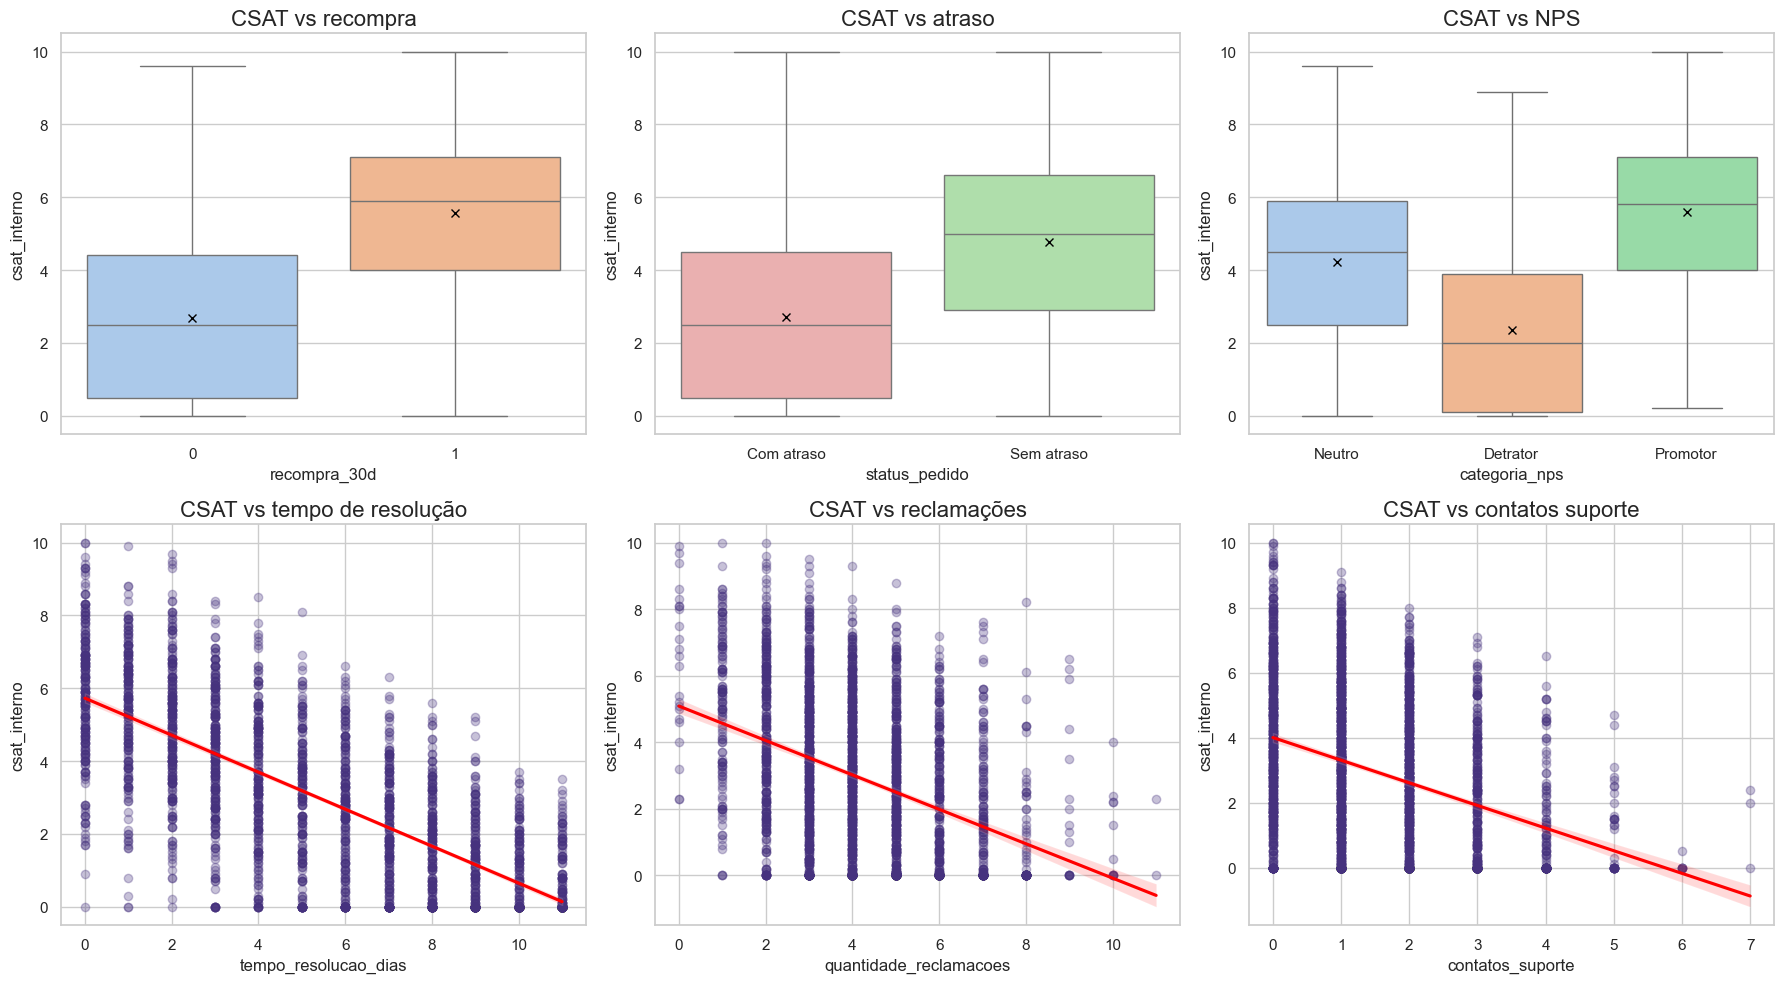

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(
    data=df,
    x="recompra_30d",
    y="csat_interno",
    palette="pastel",
    showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black"},
    ax=axes[0, 0]
)
axes[0, 0].set_title("CSAT vs recompra")

sns.boxplot(
    data=df,
    x="status_pedido",
    y="csat_interno",
    palette={"Com atraso": "#f4a6a6", "Sem atraso": "#a8e6a3"},
    showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black"},
    ax=axes[0, 1]
)
axes[0, 1].set_title("CSAT vs atraso")

sns.boxplot(
    data=df,
    x="categoria_nps",
    y="csat_interno",
    palette="pastel",
    showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black"},
    ax=axes[0, 2]
)
axes[0, 2].set_title("CSAT vs NPS")

sns.regplot(
    data=df,
    x="tempo_resolucao_dias",
    y="csat_interno",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1, 0]
)
axes[1, 0].set_title("CSAT vs tempo de resolução")

sns.regplot(
    data=df,
    x="quantidade_reclamacoes",
    y="csat_interno",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1, 1]
)
axes[1, 1].set_title("CSAT vs reclamações")

sns.regplot(
    data=df,
    x="contatos_suporte",
    y="csat_interno",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1, 2]
)
axes[1, 2].set_title("CSAT vs contatos suporte")

plt.tight_layout()
plt.show()

##### Clientes que realizam recompra apresentam níveis significativamente mais altos de CSAT, enquanto clientes que não retornam concentram-se nas faixas mais baixas.
##### Observa-se também uma relação clara entre CSAT e NPS, indicando consistência entre a satisfação imediata e a percepção geral do cliente.
##### As análises de dispersão mostram que o aumento no tempo de resolução, no número de reclamações e na quantidade de interações com suporte está diretamente associado à queda no CSAT.

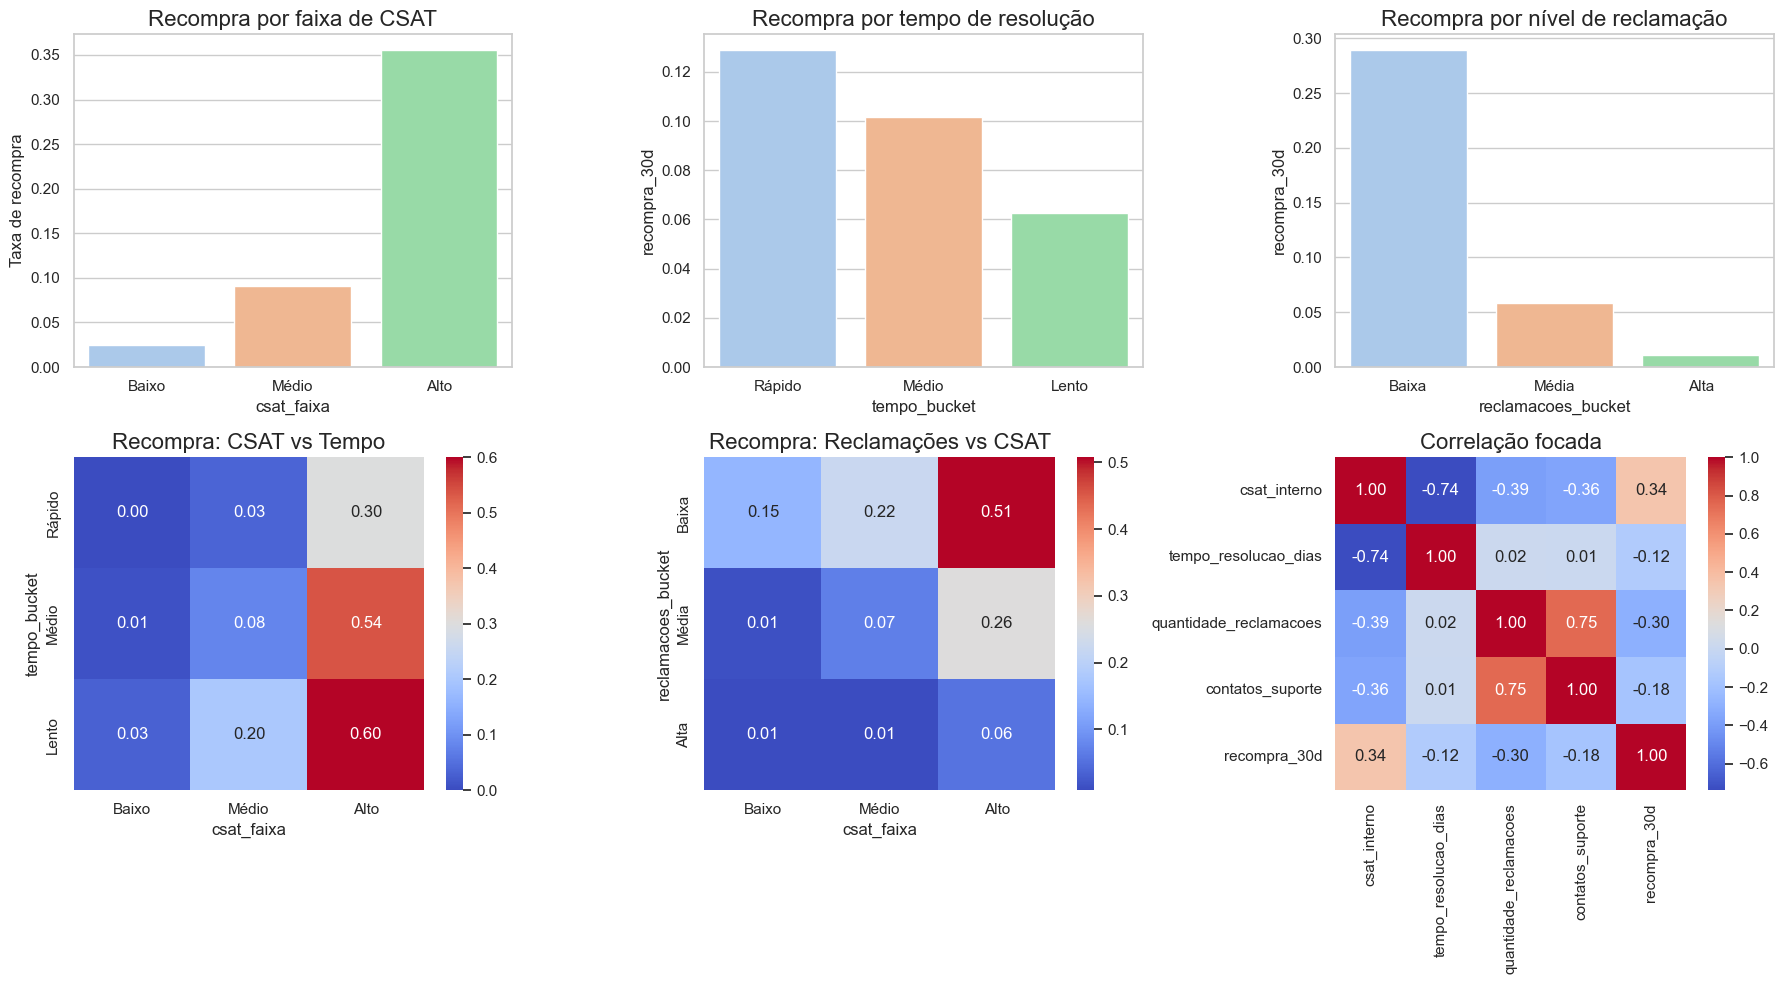

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df["csat_faixa"] = pd.cut(df["csat_interno"], bins=[-1, 3, 6, 10], labels=["Baixo", "Médio", "Alto"])
recompra_csat = df.groupby("csat_faixa")["recompra_30d"].mean().reset_index()

sns.barplot(data=recompra_csat, x="csat_faixa", y="recompra_30d", palette="pastel", ax=axes[0, 0])
axes[0, 0].set_title("Recompra por faixa de CSAT")
axes[0, 0].set_ylabel("Taxa de recompra")

df["tempo_bucket"] = pd.cut(df["tempo_resolucao_dias"], bins=[-1, 2, 5, 10], labels=["Rápido", "Médio", "Lento"])
recompra_tempo = df.groupby("tempo_bucket")["recompra_30d"].mean().reset_index()

sns.barplot(data=recompra_tempo, x="tempo_bucket", y="recompra_30d", palette="pastel", ax=axes[0, 1])
axes[0, 1].set_title("Recompra por tempo de resolução")

df["reclamacoes_bucket"] = pd.cut(df["quantidade_reclamacoes"], bins=[-1, 2, 5, 10], labels=["Baixa", "Média", "Alta"])
recompra_reclam = df.groupby("reclamacoes_bucket")["recompra_30d"].mean().reset_index()

sns.barplot(data=recompra_reclam, x="reclamacoes_bucket", y="recompra_30d", palette="pastel", ax=axes[0, 2])
axes[0, 2].set_title("Recompra por nível de reclamação")

pivot = pd.pivot_table(
    df,
    values="recompra_30d",
    index="tempo_bucket",
    columns="csat_faixa",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("Recompra: CSAT vs Tempo")

pivot2 = pd.pivot_table(
    df,
    values="recompra_30d",
    index="reclamacoes_bucket",
    columns="csat_faixa",
    aggfunc="mean"
)

sns.heatmap(pivot2, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Recompra: Reclamações vs CSAT")

cols = ["csat_interno", "tempo_resolucao_dias", "quantidade_reclamacoes", "contatos_suporte", "recompra_30d"]
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 2])
axes[1, 2].set_title("Correlação focada")

plt.tight_layout()
plt.show()

##### A recompra está diretamente ligada à qualidade da experiência do cliente.
##### Clientes com CSAT alto tendem a comprar novamente, enquanto CSAT baixo reduz drasticamente a chance de retorno.
##### Quanto maior o tempo de resolução, menor a recompra.
##### O mesmo acontece com o aumento de reclamações, que impactam negativamente a retenção.
##### No geral, uma operação eficiente, com menos problemas e resolução rápida, aumenta significativamente a recompra.

## 11. Números utilizados para a apresentação da pós

In [18]:
df.groupby("status_pedido")["nps"].mean()
pd.crosstab(df["status_pedido"], df["categoria_nps"], normalize="index")

categoria_nps,Detrator,Neutro,Promotor
status_pedido,,,
Com atraso,0.79,0.16,0.05
Sem atraso,0.36,0.32,0.31


In [19]:
df["faixa_resolucao"] = pd.cut(
    df["tempo_resolucao_dias"],
    bins=[-1,2,5,100],
    labels=["Rápido","Médio","Lento"]
)

df.groupby("faixa_resolucao")["nps"].mean()
pd.crosstab(df["faixa_resolucao"], df["categoria_nps"], normalize="index")

categoria_nps,Detrator,Neutro,Promotor
faixa_resolucao,,,
Rápido,0.64,0.24,0.12
Médio,0.73,0.17,0.10
Lento,0.79,0.15,0.05


In [20]:
df.groupby("csat_faixa")["recompra_30d"].mean()

csat_faixa
Baixo   0.02
Médio   0.09
Alto    0.36
Name: recompra_30d, dtype: float64

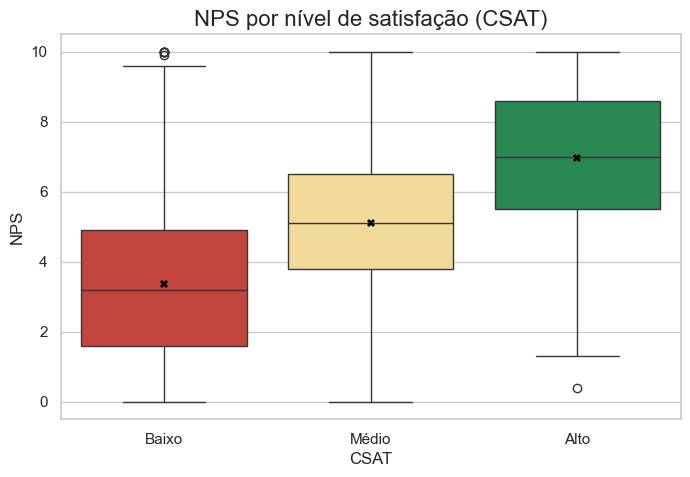

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="csat_faixa",
    y="nps",
    palette=["#d73027", "#fee08b", "#1a9850"],  # vermelho, amarelo, verde
    showmeans=True,
    meanprops={
        "marker": "X",
        "markerfacecolor": "black",
        "markersize": 6,
        "markeredgewidth": 0
    }
)

plt.title("NPS por nível de satisfação (CSAT)")
plt.xlabel("CSAT")
plt.ylabel("NPS")

plt.show()

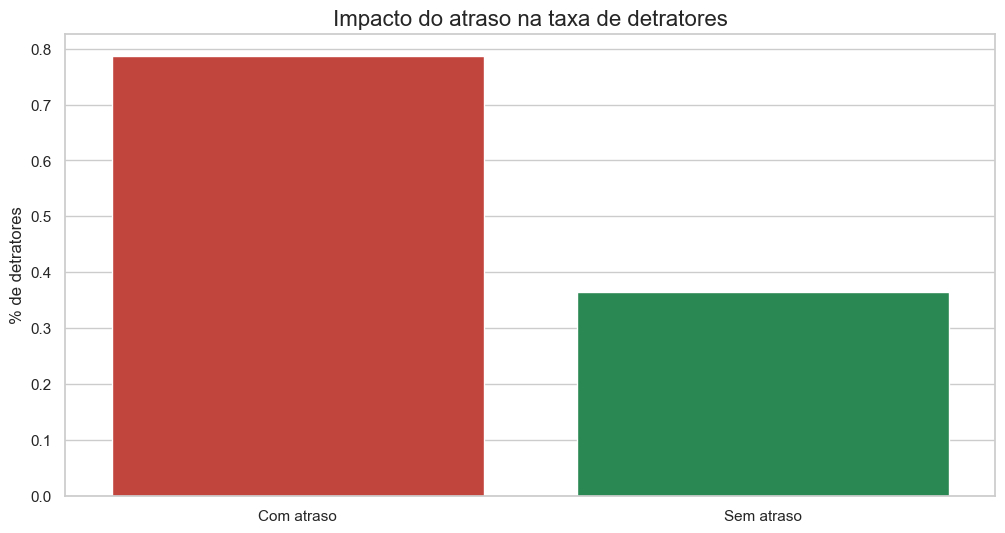

In [22]:
df["teve_atraso"] = df["atraso_entrega_dias"].apply(lambda x: "Com atraso" if x > 0 else "Sem atraso")

detratores = df[df["categoria_nps"] == "Detrator"]

taxa_detratores = df.groupby("teve_atraso")["categoria_nps"].apply(
    lambda x: (x == "Detrator").mean()
).reset_index(name="taxa_detratores")

sns.barplot(data=taxa_detratores, x="teve_atraso", y="taxa_detratores", palette =[ "#d73027", "#1a9850"])
plt.title("Impacto do atraso na taxa de detratores")
plt.ylabel("% de detratores")
plt.xlabel("")
plt.show()

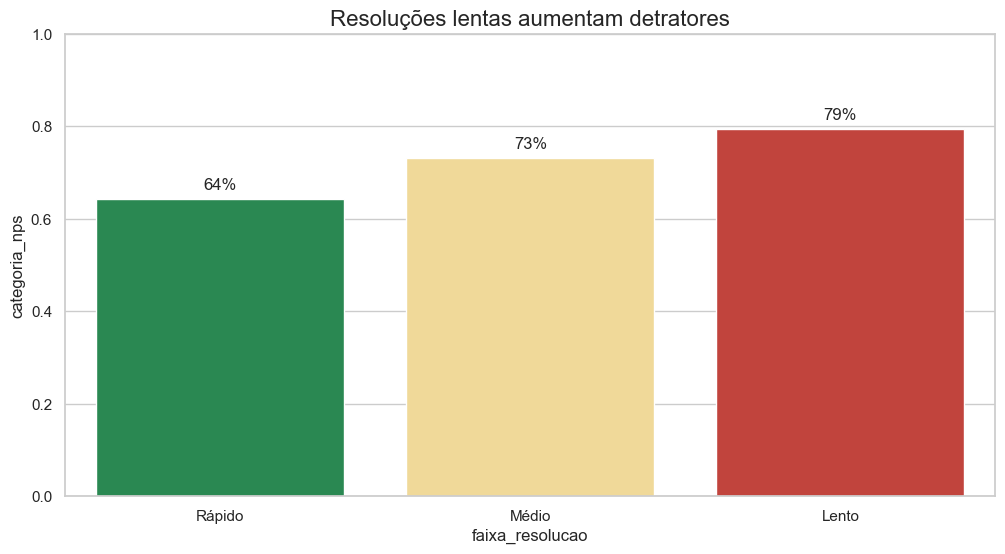

In [23]:
dados = df.groupby("faixa_resolucao")["categoria_nps"].apply(
    lambda x: (x == "Detrator").mean()
).reset_index()

sns.barplot(data=dados, x="faixa_resolucao", y="categoria_nps", palette=["#1a9850", "#fee08b", "#d73027" ])

plt.title("Resoluções lentas aumentam detratores")

for i, v in enumerate(dados["categoria_nps"]):
    plt.text(i, v + 0.02, f"{v:.0%}", ha='center')

plt.ylim(0,1)
plt.show()
plt.show()

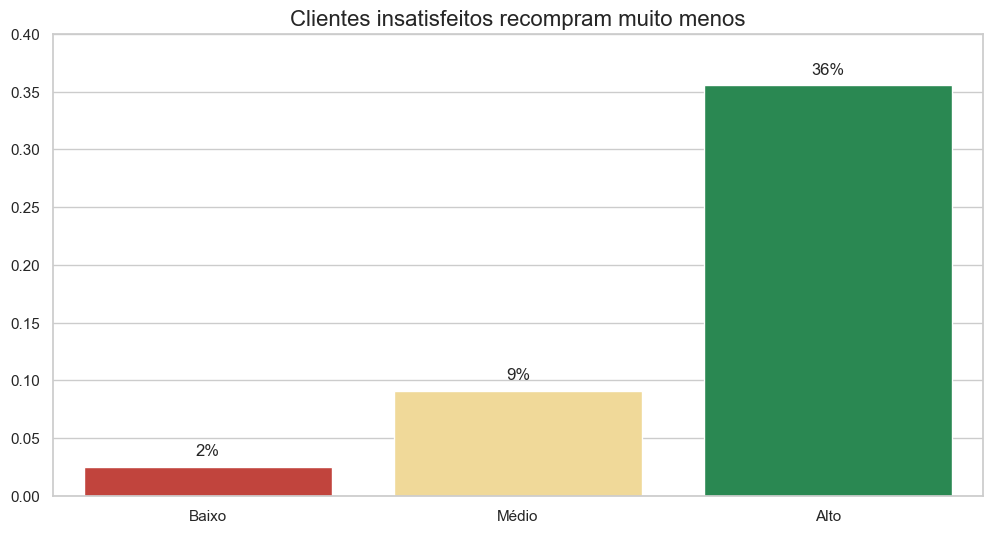

In [24]:
dados = df.groupby("csat_faixa")["recompra_30d"].mean().reset_index()

sns.barplot(data=dados, x="csat_faixa", y="recompra_30d", palette=["#d73027", "#fee08b", "#1a9850"])

plt.title("Clientes insatisfeitos recompram muito menos")

# Valores nas barras
for i, v in enumerate(dados["recompra_30d"]):
    plt.text(i, v + 0.01, f"{v:.0%}", ha='center')

plt.ylim(0,0.4)
plt.xlabel("")
plt.ylabel("")

plt.show()